In [7]:
df.to_excel('cleaned_data.xlsx', index=False)
print("✅ Cleaned data saved to cleaned_data.xlsx")
print("\n====== AUTOMATION COMPLETE ======")
print(f"Rows after cleaning : {len(df)}")
print(f"Total Revenue       : ₹{df['Purchase_Amount'].sum():,.2f}")
print(f"Average Age         : {df['Age'].mean():.1f} years")
print(f"Top Region          : {df.groupby('Region')['Purchase_Amount'].sum().idxmax()}")

✅ Cleaned data saved to cleaned_data.xlsx

====== AUTOMATION COMPLETE ======
Rows after cleaning : 14
Total Revenue       : ₹5,190.00
Average Age         : 29.7 years
Top Region          : East


In [5]:
print("====== AFTER CLEANING ======")
print(f"Total Rows         : {len(df)}")
print(f"Duplicate Rows     : {df.duplicated().sum()}")
print(f"Missing Values:\n{df.isnull().sum()}")

====== AFTER CLEANING ======
Total Rows         : 14
Duplicate Rows     : 0
Missing Values:
CustomerID         0
Name               0
Age                0
Email              0
Purchase_Amount    0
Region             0
dtype: int64


C:\Users\Sandhya\AppData\Local\Temp\ipykernel_33020\2148758821.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_data, x='Region', y='Purchase_Amount', palette='Blues_d', ax=axes[0])


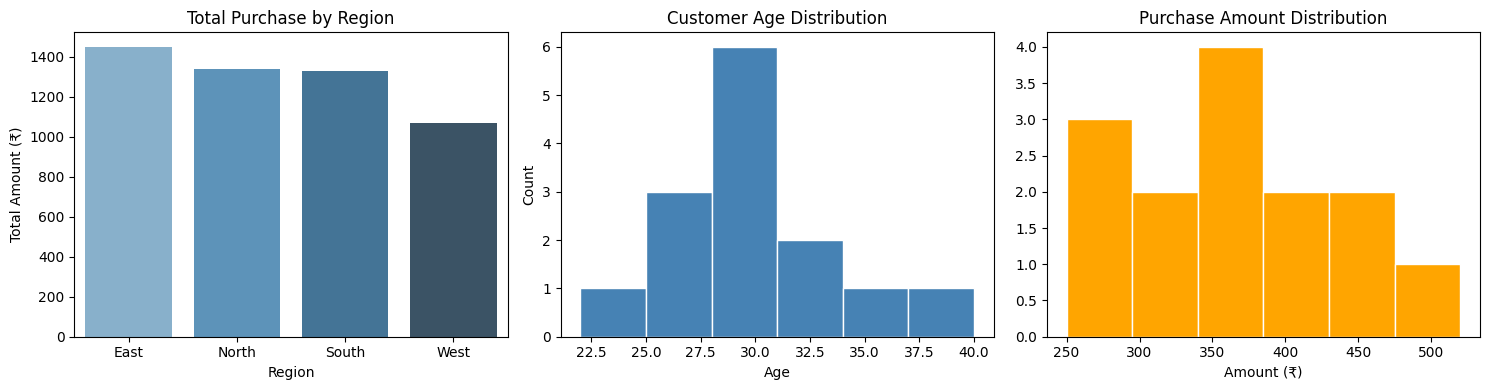

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Purchase by Region
region_data = df.groupby('Region')['Purchase_Amount'].sum().reset_index()
sns.barplot(data=region_data, x='Region', y='Purchase_Amount', palette='Blues_d', ax=axes[0])
axes[0].set_title('Total Purchase by Region')
axes[0].set_ylabel('Total Amount (₹)')

# Age Distribution
axes[1].hist(df['Age'], bins=6, color='steelblue', edgecolor='white')
axes[1].set_title('Customer Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

# Purchase Amount Distribution
axes[2].hist(df['Purchase_Amount'], bins=6, color='orange', edgecolor='white')
axes[2].set_title('Purchase Amount Distribution')
axes[2].set_xlabel('Amount (₹)')

plt.tight_layout()
plt.savefig('cleaning_report.png')
plt.show()

In [3]:
print("====== DATA QUALITY REPORT ======")
print(f"Total Rows         : {len(df)}")
print(f"Duplicate Rows     : {df.duplicated().sum()}")
print(f"Missing Values:\n{df.isnull().sum()}")


====== DATA QUALITY REPORT ======
Total Rows         : 15
Duplicate Rows     : 1
Missing Values:
CustomerID         0
Name               2
Age                3
Email              0
Purchase_Amount    3
Region             0
dtype: int64


In [4]:
# Remove duplicates
df = df.drop_duplicates()

# Fix inconsistent Region values
df['Region'] = df['Region'].str.strip().str.title()

# Fill missing Age with average
df['Age'] = df['Age'].fillna(df['Age'].mean().round(0))

# Fill missing Purchase Amount with median
df['Purchase_Amount'] = df['Purchase_Amount'].fillna(df['Purchase_Amount'].median())

# Fill missing Name with Unknown
df['Name'] = df['Name'].fillna('Unknown')

print("====== CLEANED DATA ======")
print(df)

====== CLEANED DATA ======
    CustomerID     Name   Age           Email  Purchase_Amount Region
0            1    Alice  25.0  alice@mail.com            250.0  North
1            2      Bob  30.0    bob@mail.com            450.0  South
2            3  Unknown  22.0  carol@mail.com            380.0   East
3            4    David  30.0  david@mail.com            300.0   West
4            5      Eve  28.0    eve@mail.com            520.0  North
5            6    Frank  35.0  frank@mail.com            410.0  South
6            7    Grace  26.0  grace@mail.com            380.0   East
7            8     Hank  30.0   hank@mail.com            390.0   West
8            9      Ivy  31.0    ivy@mail.com            280.0  North
9           10     Jack  29.0   jack@mail.com            470.0  South
10          11    Karen  40.0  karen@mail.com            310.0   East
11          12  Unknown  33.0    nan@mail.com            380.0   West
13          14      Leo  27.0    leo@mail.com            290.0 

In [2]:
np.random.seed(42)

data = {
    'CustomerID': [1,2,3,4,5,6,7,8,9,10,11,12,10,14,15],
    'Name': ['Alice','Bob',None,'David','Eve','Frank','Grace',
             'Hank','Ivy','Jack','Karen',None,'Jack','Leo','Mia'],
    'Age': [25,30,22,None,28,35,26,None,31,29,40,33,29,27,None],
    'Email': ['alice@mail.com','bob@mail.com','carol@mail.com',
              'david@mail.com','eve@mail.com','frank@mail.com',
              'grace@mail.com','hank@mail.com','ivy@mail.com',
              'jack@mail.com','karen@mail.com','nan@mail.com',
              'jack@mail.com','leo@mail.com','mia@mail.com'],
    'Purchase_Amount': [250,450,None,300,520,410,None,390,280,
                        470,310,None,470,290,380],
    'Region': ['North','South','East','West','north','SOUTH',
               'East','West','North','south','East','West',
               'south','North','East']
}

df = pd.DataFrame(data)
print("====== RAW MESSY DATA ======")
print(df)

====== RAW MESSY DATA ======
    CustomerID   Name   Age           Email  Purchase_Amount Region
0            1  Alice  25.0  alice@mail.com            250.0  North
1            2    Bob  30.0    bob@mail.com            450.0  South
2            3   None  22.0  carol@mail.com              NaN   East
3            4  David   NaN  david@mail.com            300.0   West
4            5    Eve  28.0    eve@mail.com            520.0  north
5            6  Frank  35.0  frank@mail.com            410.0  SOUTH
6            7  Grace  26.0  grace@mail.com              NaN   East
7            8   Hank   NaN   hank@mail.com            390.0   West
8            9    Ivy  31.0    ivy@mail.com            280.0  North
9           10   Jack  29.0   jack@mail.com            470.0  south
10          11  Karen  40.0  karen@mail.com            310.0   East
11          12   None  33.0    nan@mail.com              NaN   West
12          10   Jack  29.0   jack@mail.com            470.0  south
13          14    L

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns